In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
import missingno as msno 
from ydata_profiling import ProfileReport 

## 결측치 제거

In [86]:
df_raw = pd.read_csv('dataset/heart.csv')
df_raw.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


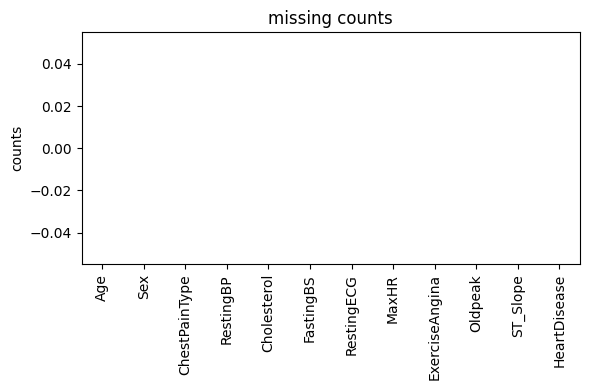

In [87]:
# 결측치는 없으나 0이 결측치로 사용됨
missing_counts = df_raw.isnull().sum()
print(missing_counts)

fig, ax = plt.subplots(figsize=(6, 4))
missing_counts.plot(kind="bar")
ax.set_title("missing counts")
ax.set_ylabel("counts")
plt.tight_layout()
plt.savefig("output/heart-figures/missing_counts.png", dpi=120)
plt.show()

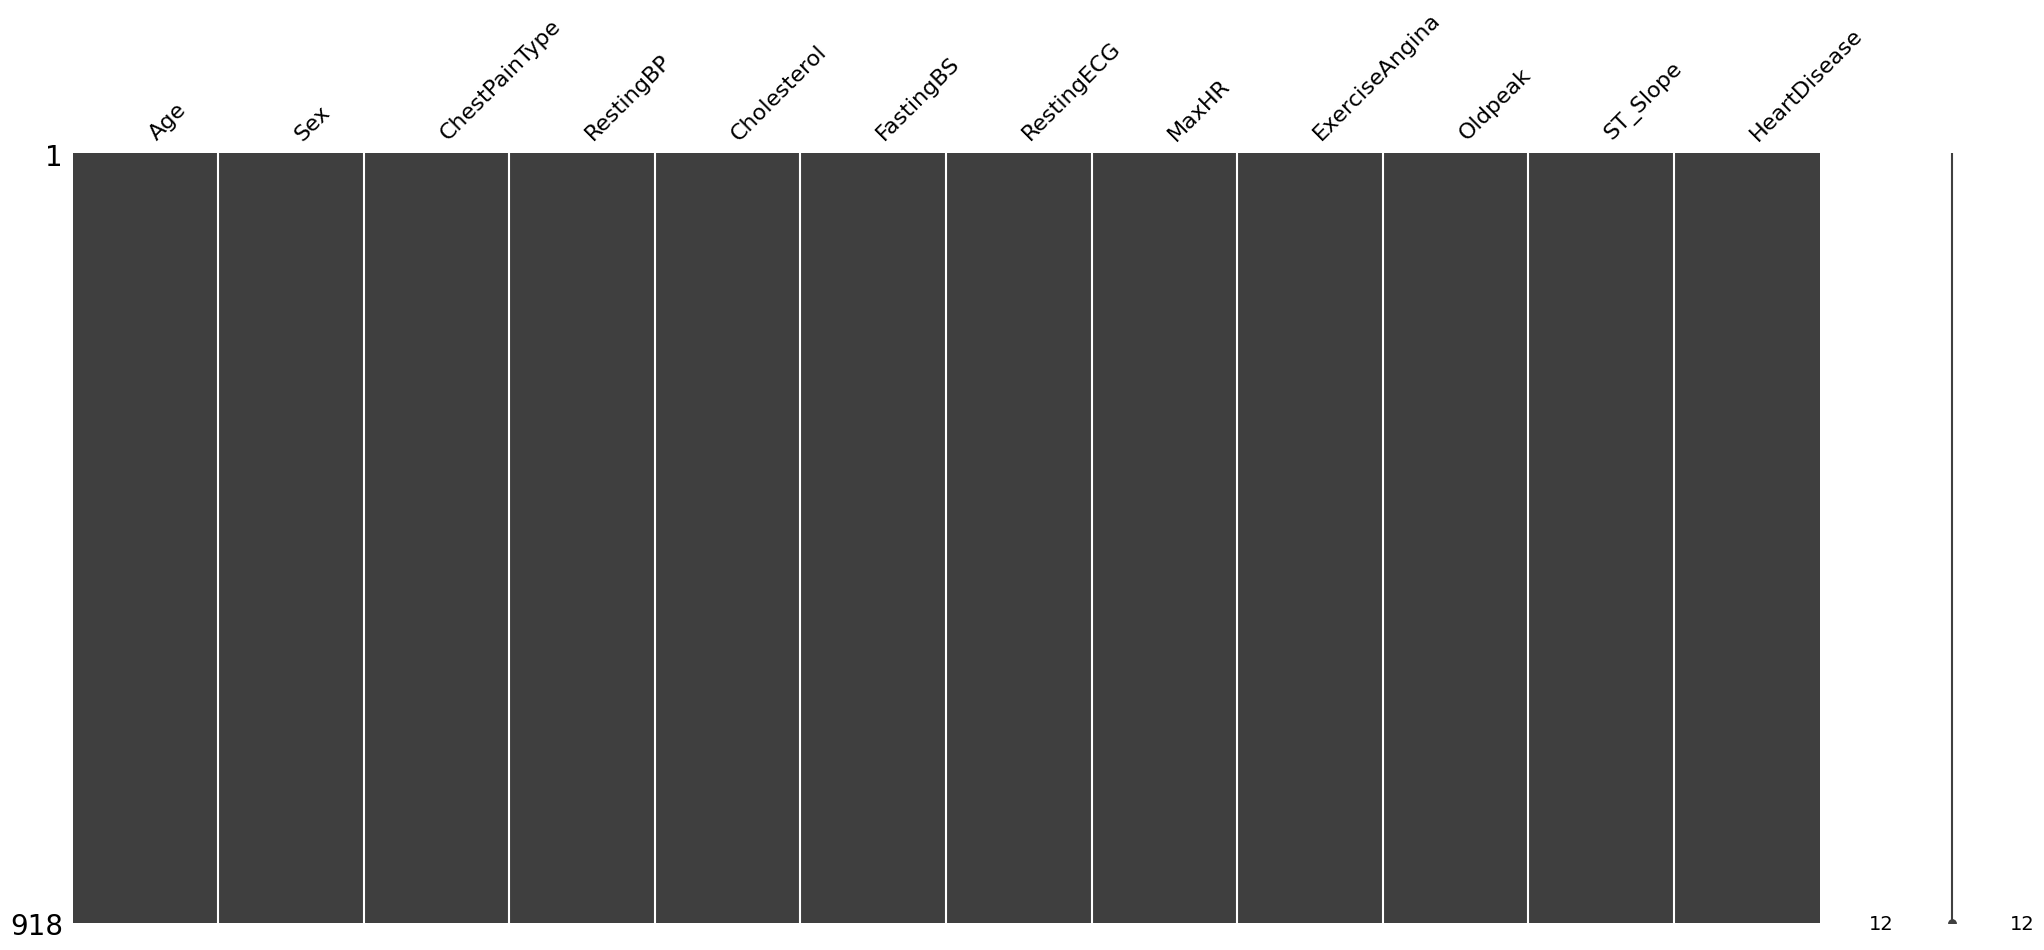

In [88]:
# missingno로 결측치 패턴 확인 (표준 NaN은 없어 전체 흰 행 없이 채워진 패턴이 보이는 게 정상)
msno.matrix(df_raw)
plt.savefig("output/heart-figures/missingno_matrix.png", dpi=120)
plt.show()

In [89]:
dup_count = df_raw.duplicated().sum()
print("duplicate cnt", dup_count)

duplicate cnt 0


In [90]:
print((df_raw[['RestingBP','Cholesterol']]==0).sum())

RestingBP        1
Cholesterol    172
dtype: int64


## 0값 처리 전 주요 변수별 분포
RestingBP, Cholesterol의 0값을 처리하기 전에 주요 수치형 변수들의 분포를 히스토그램으로 먼저 확인한다.

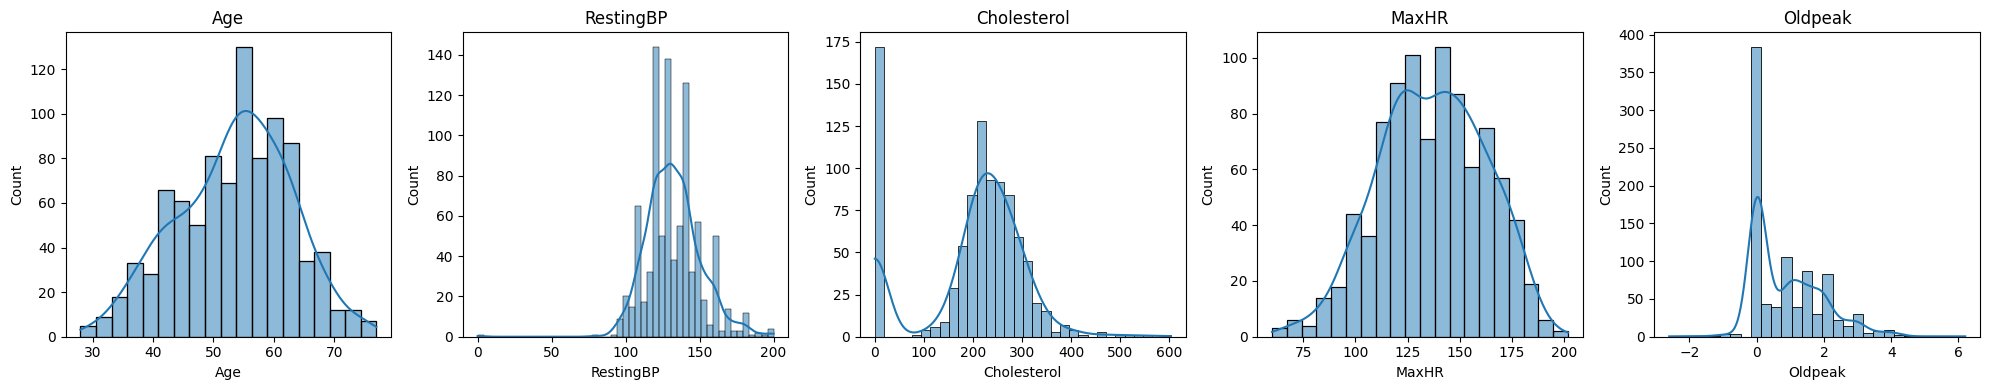

In [91]:
raw_numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(1, len(raw_numeric_cols), figsize=(4 * len(raw_numeric_cols), 4))
for ax, col in zip(axes, raw_numeric_cols):
    sns.histplot(df_raw[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("output/heart-figures/raw_distributions_hist.png", dpi=120)
plt.show()

In [92]:
df_raw = df_raw[df_raw['RestingBP'] != 0]
print(len(df_raw['RestingBP']))
print(len(df_raw))

917
917


In [93]:
df_raw['Cholesterol'] = df_raw['Cholesterol'].replace(0, np.nan)
df_raw['Cholesterol'] = df_raw.groupby('HeartDisease')['Cholesterol'].transform(lambda x: x.fillna(x.median()))

print(df_raw['Cholesterol'].mean())

244.57360959651035


## 이상치 확인

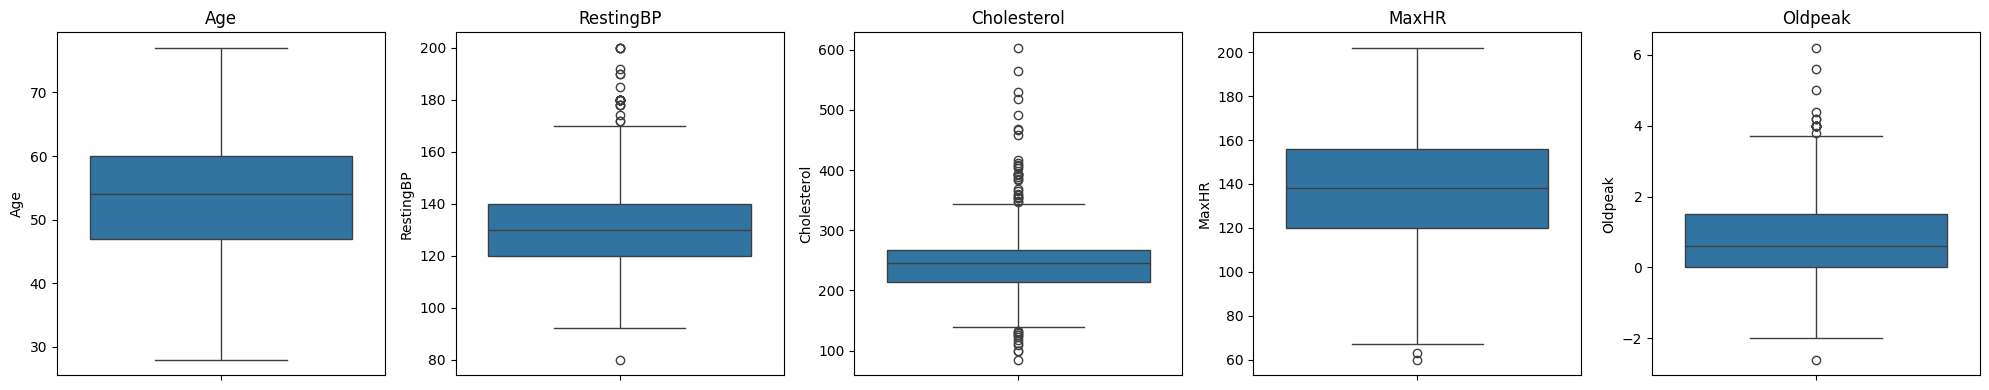

In [94]:
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df_raw[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("output/heart-figures/outliers_boxplot.png", dpi=120)
plt.show()

In [95]:
# IQR 기준 이상치 개수 확인
for col in numeric_cols:
    q1, q3 = df_raw[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_count = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()
    print(f"{col}: {outlier_count}개 (정상 범위 {lower:.1f} ~ {upper:.1f})")

Age: 0개 (정상 범위 27.5 ~ 79.5)
RestingBP: 27개 (정상 범위 90.0 ~ 170.0)
Cholesterol: 41개 (정상 범위 134.5 ~ 346.5)
MaxHR: 2개 (정상 범위 66.0 ~ 210.0)
Oldpeak: 16개 (정상 범위 -2.2 ~ 3.8)


## 다중공선성 분석

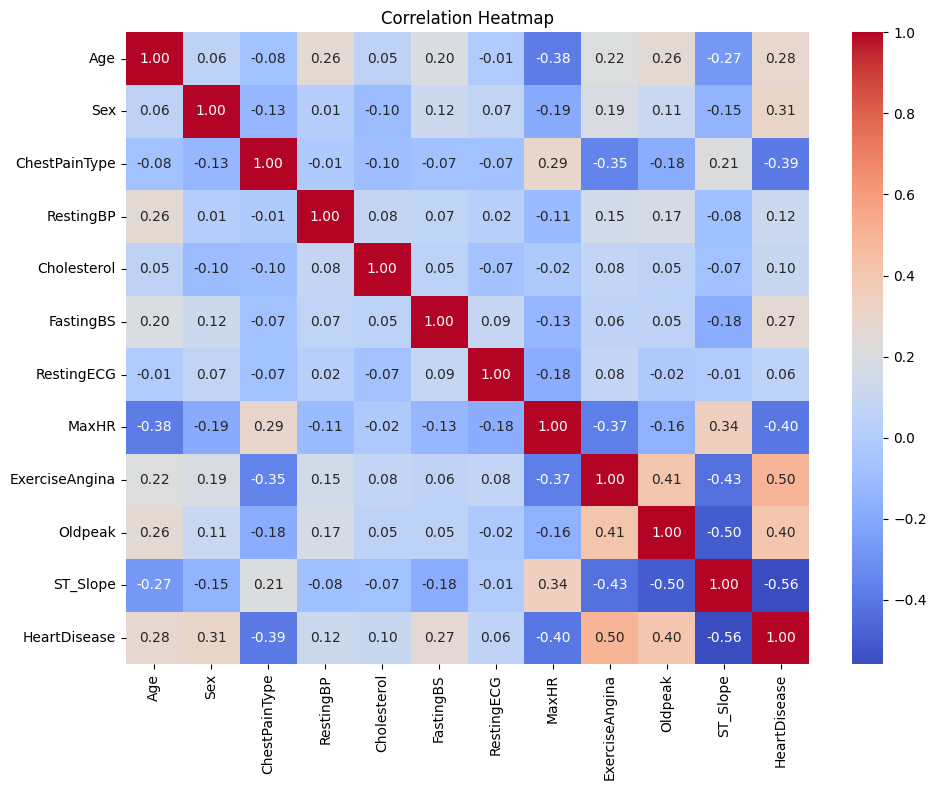

In [96]:
# 상관관계 분석을 위해 범주형 변수만 임시로 인코딩한 사본 생성 (df_raw 자체는 변경하지 않음)
df_corr = df_raw.copy()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig("output/heart-figures/correlation_heatmap.png", dpi=120)
plt.show()

## 주요 변수별 분포 (타깃 대비)

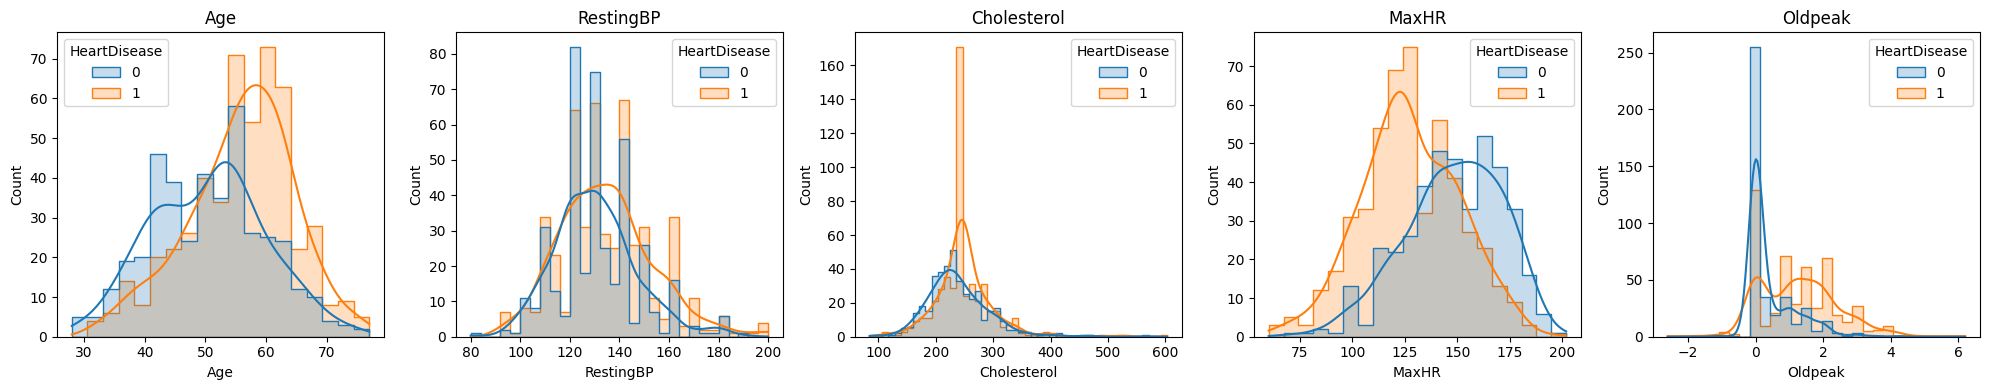

In [97]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df_raw, x=col, hue='HeartDisease', kde=True, ax=ax, element='step')
    ax.set_title(col)
plt.tight_layout()
plt.savefig("output/heart-figures/distribution_by_target.png", dpi=120)
plt.show()

## 스케일러 생성

In [98]:
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

scalers = {
    'StandardScaler': standard_scaler,
    'MinMaxScaler': minmax_scaler,
    'RobustScaler': robust_scaler,
}

## 범주형 변수 인코딩

In [99]:
# 이진 범주형 변수: 0/1로 매핑
df_raw['Sex'] = df_raw['Sex'].map({'M': 1, 'F': 0})
df_raw['ExerciseAngina'] = df_raw['ExerciseAngina'].map({'Y': 1, 'N': 0})

# 다범주 변수: One-Hot Encoding (dtype=int로 명시, pandas 2.0+ 기본값이 bool로 바뀜)
df_raw = pd.get_dummies(df_raw, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True)

print(df_raw.dtypes)
df_raw.head()

Age                    int64
Sex                    int64
RestingBP              int64
Cholesterol          float64
FastingBS              int64
MaxHR                  int64
ExerciseAngina         int64
Oldpeak              float64
HeartDisease           int64
ChestPainType_ATA       bool
ChestPainType_NAP       bool
ChestPainType_TA        bool
RestingECG_Normal       bool
RestingECG_ST           bool
ST_Slope_Flat           bool
ST_Slope_Up             bool
dtype: object


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289.0,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,0,160,180.0,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,1,130,283.0,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,0,138,214.0,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,1,150,195.0,0,122,0,0.0,0,False,True,False,True,False,False,True


## 데이터 프로파일링 리포트

In [100]:
profile = ProfileReport(df_raw, title="Heart Disease Profiling Report", explorative=True)
profile.to_file("output/heart-figures/profile_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 234.15it/s]


## Train/Test 분리

In [101]:
X = df_raw.drop('HeartDisease', axis=1)
y = df_raw['HeartDisease']

In [102]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

## 스케일링 적용 (Train 기준 fit, 데이터 누수 방지)

In [103]:
# train으로만 fit하고 train/test 둘 다 transform → 데이터 누수 방지
scaled_train_results = {}
scaled_test_results = {}

for name, scaler in scalers.items():
    train_scaled = scaler.fit_transform(X_train[numeric_cols])
    test_scaled = scaler.transform(X_test[numeric_cols])
    scaled_train_results[name] = pd.DataFrame(train_scaled, columns=numeric_cols, index=X_train.index)
    scaled_test_results[name] = pd.DataFrame(test_scaled, columns=numeric_cols, index=X_test.index)

scaled_train_results['RobustScaler'].head()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
795,-0.923077,-0.5,-0.111111,1.555556,0.200000
25,-1.384615,0.0,-0.685185,1.111111,-0.333333
84,0.153846,1.0,-0.611111,-0.361111,0.333333
10,-1.307692,0.0,-0.648148,0.111111,-0.333333
344,-0.230769,-0.5,0.000000,-0.944444,-0.333333


## 전처리 결과 저장 (모델링 노트북에서 사용)

In [104]:
# 트리 모델용: 인코딩만 하고 스케일링 안 한 원본 그대로 저장
X_train.assign(HeartDisease=y_train).to_csv("dataset/heart_train.csv", index=False)
X_test.assign(HeartDisease=y_test).to_csv("dataset/heart_test.csv", index=False)

# 로지스틱회귀/SVM 등 스케일에 민감한 모델용: 스케일러 3종을 모두 적용본으로 저장 (어떤 스케일러가 더 나은지 모델링 단계에서 비교)
scaler_suffix = {'StandardScaler': 'scaled', 'MinMaxScaler': 'minmax', 'RobustScaler': 'robust'}

for name, suffix in scaler_suffix.items():
    X_train_scaled = X_train.copy()
    X_train_scaled[numeric_cols] = scaled_train_results[name]
    X_test_scaled = X_test.copy()
    X_test_scaled[numeric_cols] = scaled_test_results[name]

    X_train_scaled.assign(HeartDisease=y_train).to_csv(f"dataset/heart_train_{suffix}.csv", index=False)
    X_test_scaled.assign(HeartDisease=y_test).to_csv(f"dataset/heart_test_{suffix}.csv", index=False)

print("저장 완료")

저장 완료
